In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols


In [27]:
df = pd.read_csv("D:\Work\Econometrics\College_Scorecard_Raw_Data_10032025\MERGED2020_21_PP.csv", low_memory=False)
df2 = pd.read_csv("D:\Work\Econometrics\College_Scorecard_Raw_Data_10032025\MERGED2023_24_PP.csv", low_memory=False)

cols = ["UNITID", "INSTNM", "SAT_AVG", "MD_EARN_WNE_P10","AVGFACSAL", "CONTROL", "UGDS_MEN"]
cols2 = ["UNITID", "LATITUDE", "LONGITUDE"]
mysample = df[cols].merge(df2[cols2], on="UNITID", how='left').copy()
for col in cols[2:]:
    mysample[col] = pd.to_numeric(mysample[col], errors='coerce') #Transform the data to numbers
mysample = mysample.dropna(subset=['MD_EARN_WNE_P10']) #Drop empty earnings

# Rename variables
mysample = mysample.rename(columns={"MD_EARN_WNE_P10": "Earnings"}) #Rename the column

In [28]:
mysample.head()

,UNITID,INSTNM,SAT_AVG,Earnings,AVGFACSAL,CONTROL,UGDS_MEN,LATITUDE,LONGITUDE
0,100654,Alabama A & M University,959.0,40628.0,7599.0,1,0.3978,34.783368,-86.568502
1,100663,University of Alabama at Birmingham,1245.0,54501.0,11380.0,1,0.3816,33.505697,-86.799345
2,100690,Amridge University,NaN,37621.0,4545.0,2,0.2886,32.362609,-86.174010
3,100706,University of Alabama in Huntsville,1300.0,61767.0,9697.0,1,0.5891,34.724557,-86.640449
4,100724,Alabama State University,938.0,34502.0,7194.0,1,0.3605,32.364317,-86.295677


Text(0.5, 1.0, 'Relationship between SAT Score and Earnings')

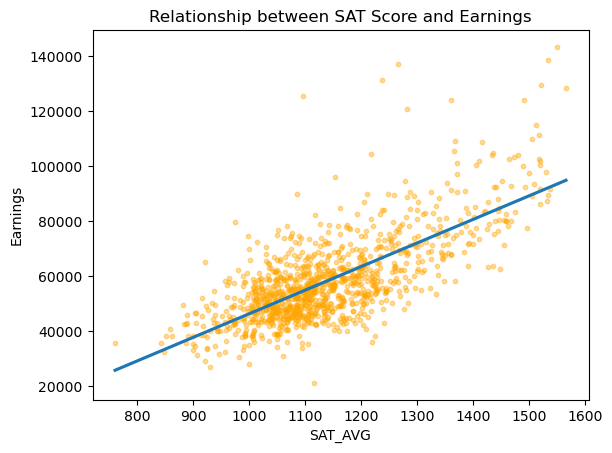

In [35]:
#SAT_SCORE's effect on earnings
sns.regplot(x='SAT_AVG',
                y='Earnings',
                data=mysample,
                scatter_kws={'color':'orange',
                             'alpha':0.4,
                             's':10},
                ci=False)

plt.title('Relationship between SAT Score and Earnings')

Text(0.5, 0, 'Average Faculty Salaries per month')

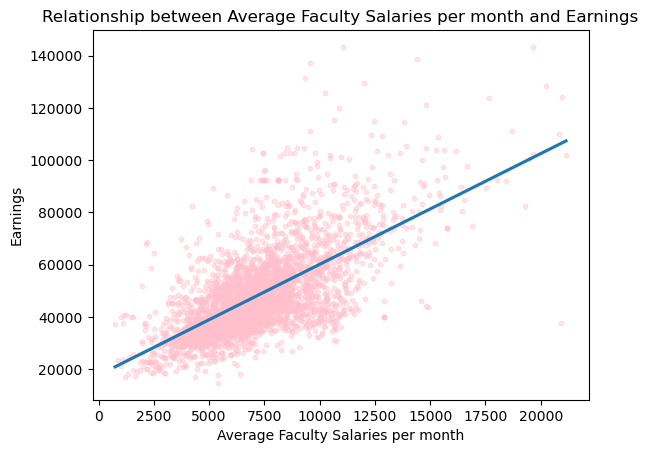

In [36]:
#Relationship between average faculty salaries per month and earnings
sns.regplot(x='AVGFACSAL',
                y='Earnings',
                data=mysample,
                scatter_kws={'color':'pink',
                             'alpha':0.4,
                             's':10},
                ci=False)

plt.title('Relationship between Average Faculty Salaries per month and Earnings')
plt.xlabel("Average Faculty Salaries per month")

C:\Users\Allen Pan\AppData\Local\Temp\ipykernel_15300\35847561.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Public','Private nonprofit','Private for-profit'])


Text(0.5, 0, 'Institusion Type')

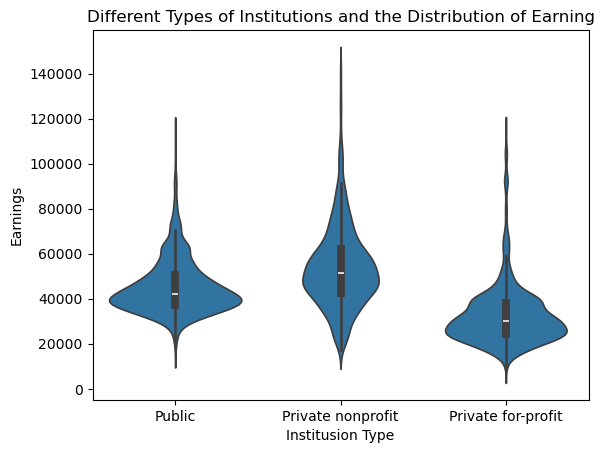

In [32]:
#Relationship between type of school and earnings
ax = sns.violinplot(x='CONTROL',
               y='Earnings',
               data=mysample)

plt.title('Different Types of Institutions and the Distribution of Earning')
ax.set_xticklabels(['Public','Private nonprofit','Private for-profit'])
plt.xlabel("Institusion Type")


Text(0.5, 1.0, 'US Geographical Income Distribution')

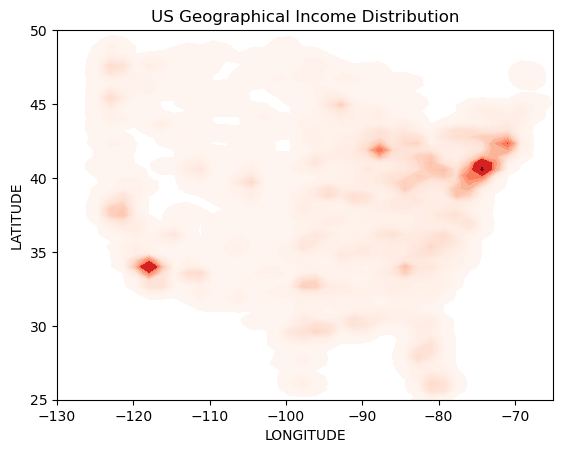

In [ ]:
#To see the different earning level across US regions
sns.kdeplot(
    data=mysample,
    x="LONGITUDE",
    y="LATITUDE",
    weights=mysample["Earnings"],
    fill=True,
    bw_adjust=0.2,   #Less smoothness
    levels=30,
    thresh=0.001,    #Less threshold
    cmap="Reds",
)
plt.xlim(-130,-65)
plt.ylim(25,50)
plt.title("US Geographical Income Distribution")


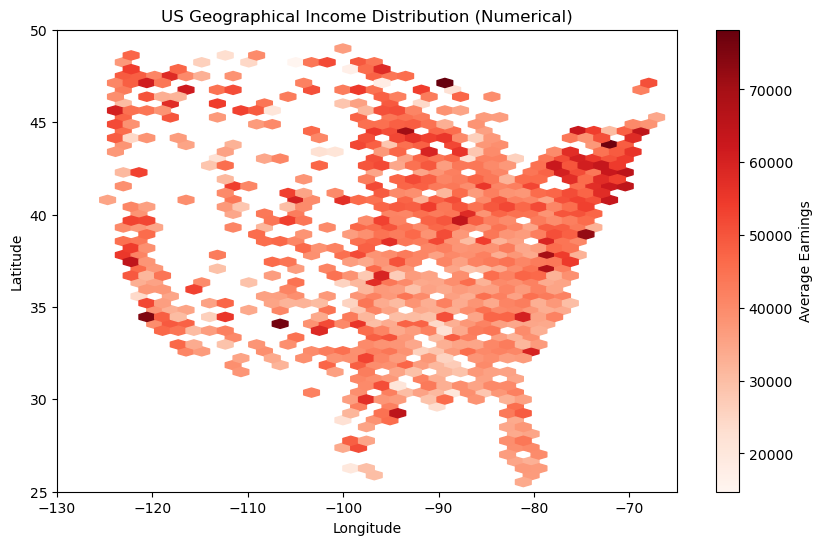

In [33]:
#To see the different earning level across US regions
plt.figure(figsize=(10,6))
plt.hexbin(
    mysample["LONGITUDE"],
    mysample["LATITUDE"],
    C=mysample["Earnings"],
    gridsize=200,               #Number of hex
    reduce_C_function=np.mean,
    cmap="Reds"
)
plt.xlim(-130,-65)
plt.ylim(25,50)
plt.colorbar(label="Average Earnings")
plt.title("US Geographical Income Distribution (Numerical)")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()